In [30]:
import pandas as pd
import numpy as np

In [31]:
movies_df = pd.read_csv("../data/ml-latest-small/movies.csv")
ratings_df = pd.read_csv("../data/ml-latest-small/ratings.csv")
tags_df = pd.read_csv("../data/ml-latest-small/tags.csv")

In [32]:
movies_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [33]:
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [34]:
tags_df.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [35]:
print("Movies dataset:")
print(f"Shape: {movies_df.shape}")
print(f"Unique movies: {movies_df['movieId'].nunique()}")

print("\nRatings dataset:")
print(f"Shape: {ratings_df.shape}")
print(f"Unique users: {ratings_df['userId'].nunique()}")
print(f"Unique movies rated: {ratings_df['movieId'].nunique()}")
print(f"Rating range: {ratings_df['rating'].min()} - {ratings_df['rating'].max()}")

print("\nTags dataset:")
print(f"Shape: {tags_df.shape}")

Movies dataset:
Shape: (9742, 3)
Unique movies: 9742

Ratings dataset:
Shape: (100836, 4)
Unique users: 610
Unique movies rated: 9724
Rating range: 0.5 - 5.0

Tags dataset:
Shape: (3683, 4)


In [36]:
movies_df['year'] = movies_df['title'].str.extract(r'\((\d{4})\)', expand=False)
movies_df['year'].isnull().sum()

13

In [37]:
movies_df.shape

(9742, 4)

In [38]:
movies_df = movies_df.dropna(axis=0, subset=['year']) 

In [39]:
movies_df.shape

(9729, 4)

In [40]:
movies_df['year'].dtype

dtype('O')

In [41]:
movies_df['year'].unique()

array(['1995', '1994', '1996', '1976', '1992', '1967', '1993', '1964',
       '1977', '1965', '1982', '1990', '1991', '1989', '1937', '1940',
       '1969', '1981', '1973', '1970', '1955', '1959', '1968', '1988',
       '1997', '1972', '1943', '1952', '1951', '1957', '1961', '1958',
       '1954', '1934', '1944', '1960', '1963', '1942', '1941', '1953',
       '1939', '1950', '1946', '1945', '1938', '1947', '1935', '1936',
       '1956', '1949', '1932', '1975', '1974', '1971', '1979', '1987',
       '1986', '1980', '1978', '1985', '1966', '1962', '1983', '1984',
       '1948', '1933', '1931', '1922', '1998', '1929', '1930', '1927',
       '1928', '1999', '2000', '1926', '1919', '1921', '1925', '1923',
       '2001', '2002', '2003', '1920', '1915', '1924', '2004', '1916',
       '1917', '2005', '2006', '1902', '1903', '2007', '2008', '2009',
       '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017',
       '2018', '1908'], dtype=object)

In [42]:
from sklearn.preprocessing import MultiLabelBinarizer

movies_df['genre_list'] = movies_df['genres'].str.split('|')
mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(
    mlb.fit_transform(movies_df['genre_list']),
    columns=['genre_' + genre for genre in mlb.classes_],
    index=movies_df.index
)
movies_df = pd.concat([movies_df, genre_encoded], axis=1)

movies_df.head()

,movieId,title,genres,year,genre_list,genre_(no genres listed),genre_Action,genre_Adventure,genre_Animation,genre_Children,...,genre_Film-Noir,genre_Horror,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995,"[Adventure, Animation, Children, Comedy, Fantasy]",0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995,"[Adventure, Children, Fantasy]",0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),Comedy|Romance,1995,"[Comedy, Romance]",0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995,"[Comedy, Drama, Romance]",0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II (1995),Comedy,1995,[Comedy],0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [43]:
movie_stats = ratings_df.groupby('movieId').agg(
    avg_rating=('rating', 'mean'),
    num_ratings=('rating', 'count')
).reset_index()

movies_df = movies_df.merge(movie_stats, on='movieId', how='left')
movies_df[['avg_rating', 'num_ratings']] = movies_df[['avg_rating', 'num_ratings']].fillna(0)

In [45]:
movies_df['year'] = pd.to_numeric(movies_df['year'], errors='coerce')
# normalize year
movies_df['year_normalized'] = (
    (movies_df['year'] - movies_df['year'].min()) /
    (movies_df['year'].max() - movies_df['year'].min())
)

# normalize num_ratings
max_ratings = movies_df['num_ratings'].max()
if max_ratings > 0:
    movies_df['num_ratings'] /= max_ratings
else:
    movies_df['num_ratings'] = 0.0

movies_df['avg_rating_normalized'] = movies_df['avg_rating'] / 5.0

In [46]:
movies_df.head()

,movieId,title,genres,year,genre_list,genre_(no genres listed),genre_Action,genre_Adventure,genre_Animation,genre_Children,...,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western,avg_rating,num_ratings,year_normalized,avg_rating_normalized
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995,"[Adventure, Animation, Children, Comedy, Fantasy]",0,0,1,1,1,...,0,0,0,0,0,0,3.920930,0.653495,0.801724,0.784186
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995,"[Adventure, Children, Fantasy]",0,0,1,0,1,...,0,0,0,0,0,0,3.431818,0.334347,0.801724,0.686364
2,3,Grumpier Old Men (1995),Comedy|Romance,1995,"[Comedy, Romance]",0,0,0,0,0,...,0,1,0,0,0,0,3.259615,0.158055,0.801724,0.651923
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995,"[Comedy, Drama, Romance]",0,0,0,0,0,...,0,1,0,0,0,0,2.357143,0.021277,0.801724,0.471429
4,5,Father of the Bride Part II (1995),Comedy,1995,[Comedy],0,0,0,0,0,...,0,0,0,0,0,0,3.071429,0.148936,0.801724,0.614286


In [47]:
genre_cols = [c for c in movies_df.columns if c.startswith('genre_')]

movie_feature_cols = (
    genre_cols +
    ['year_normalized', 'num_ratings', 'avg_rating_normalized']
)

movie_features = movies_df[['movieId'] + movie_feature_cols].copy()

In [48]:
data = ratings_df.merge(movie_features, on='movieId', how='left')
data.head()

,userId,movieId,rating,timestamp,genre_list,genre_(no genres listed),genre_Action,genre_Adventure,genre_Animation,genre_Children,...,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western,year_normalized,num_ratings,avg_rating_normalized
0,1,1,4.0,964982703,"[Adventure, Animation, Children, Comedy, Fantasy]",0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.801724,0.653495,0.784186
1,1,3,4.0,964981247,"[Comedy, Romance]",0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.801724,0.158055,0.651923
2,1,6,4.0,964982224,"[Action, Crime, Thriller]",0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.801724,0.310030,0.789216
3,1,47,5.0,964983815,"[Mystery, Thriller]",0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.801724,0.617021,0.795074
4,1,50,5.0,964982931,"[Crime, Mystery, Thriller]",0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.801724,0.620061,0.847549


In [50]:
data.shape

(100836, 28)

In [49]:
data.isna().sum().sum()

432

In [53]:
data.dropna(inplace=True)

In [54]:
data.shape

(100818, 28)

In [55]:
genre_cols

['genre_list',
 'genre_(no genres listed)',
 'genre_Action',
 'genre_Adventure',
 'genre_Animation',
 'genre_Children',
 'genre_Comedy',
 'genre_Crime',
 'genre_Documentary',
 'genre_Drama',
 'genre_Fantasy',
 'genre_Film-Noir',
 'genre_Horror',
 'genre_IMAX',
 'genre_Musical',
 'genre_Mystery',
 'genre_Romance',
 'genre_Sci-Fi',
 'genre_Thriller',
 'genre_War',
 'genre_Western']

In [56]:
# Now we want to create syntetic users so that we can train the neural network
# NOTE: these are our assumptions
archetypes = {
    'sci_fi_fan': {'genre_Sci-Fi': 0.9, 'genre_Action': 0.7, 'genre_Adventure': 0.6, 'genre_Fantasy': 0.8},
    'romance_fan': {'genre_Romance': 0.9, 'genre_Comedy': 0.7, 'genre_Drama': 0.6},
    'horror_fan': {'genre_Horror': 0.9, 'genre_Thriller': 0.7, 'genre_Mystery': 0.5},
    'family_fan': {'genre_Children': 0.8, 'genre_Animation': 0.8, 'genre_Comedy': 0.6},
    'documentary_fan': {'genre_Documentary': 0.9, 'genre_War': 0.5, 'genre_Biography': 0.5},
    'action_fan': {'genre_Action': 0.9, 'genre_Adventure': 0.8, 'genre_Thriller': 0.7, 'genre_Western': 0.6},
    'mystery_fan': {'genre_Mystery': 0.9, 'genre_Crime': 0.8, 'genre_Thriller': 0.7, 'genre_Drama': 0.5},
    'oldschool_fan': {'genre_Musical': 0.8, 'genre_IMAX': 0.8, 'genre_Western': 0.7}
}

In [57]:
n_synthetic_users = 1000

viewing_contexts = {
    'alone': 0.4,
    'partner': 0.3,
    'family': 0.2,
    'friends': 0.1
}

age_mapping = {'teen': 0.2, 'young_adult': 0.4, 'adult': 0.7, 'senior': 0.9}

In [58]:
synthetic_users = []

for user_id in range(n_synthetic_users):
    user_data = {
        'user_id': user_id,
        'viewing_context': np.random.choice(list(viewing_contexts.keys()), p=list(viewing_contexts.values())),
        'age_normalized': age_mapping[np.random.choice(list(age_mapping.keys()))]
    }
    
    # We make the preference for all genre 0.3 so we dont have NaN values
    preferences = {genre: 0.3 for genre in genre_cols}
    
    if np.random.random() < 0.7:
        archetype = np.random.choice(list(archetypes.keys()))
        user_data['archetype'] = archetype
        
        for genre, pref_value in archetypes[archetype].items():
            if genre in preferences:
                preferences[genre] = pref_value
    else:
        user_data['archetype'] = 'mixed'
        for genre in genre_cols:
            preferences[genre] = np.random.beta(2, 2)
    
    for genre in preferences:
        noise_level = 0.15 if user_data['archetype'] == 'mixed' else 0.1
        preferences[genre] = np.clip(preferences[genre] + np.random.normal(0, noise_level), 0, 1)
    
    user_data.update(preferences)
    synthetic_users.append(user_data)

synthetic_users_df = pd.DataFrame(synthetic_users)

In [59]:
synthetic_users_df.head()

,user_id,viewing_context,age_normalized,archetype,genre_list,genre_(no genres listed),genre_Action,genre_Adventure,genre_Animation,genre_Children,...,genre_Film-Noir,genre_Horror,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western
0,0,partner,0.4,mystery_fan,0.187088,0.179521,0.394548,0.286225,0.305795,0.285156,...,0.331401,0.188010,0.439162,0.291127,0.808204,0.538103,0.323461,0.703839,0.334667,0.523001
1,1,alone,0.9,mystery_fan,0.224669,0.289269,0.249487,0.381654,0.336048,0.346845,...,0.482029,0.198525,0.218733,0.311535,0.918333,0.400365,0.371750,0.728331,0.331215,0.120742
2,2,family,0.2,action_fan,0.303840,0.267606,0.979021,1.000000,0.227344,0.233328,...,0.283476,0.368306,0.161675,0.301102,0.373465,0.130296,0.315205,0.668936,0.329156,0.510509
3,3,family,0.2,mixed,0.364631,0.697191,0.069616,0.000000,0.290057,0.255449,...,0.552925,0.393767,0.606902,0.388777,0.028160,0.309515,0.562303,0.841356,0.780354,0.796037
4,4,alone,0.7,oldschool_fan,0.145638,0.250339,0.186402,0.257110,0.270702,0.235827,...,0.294373,0.279342,0.851877,0.748866,0.390731,0.339603,0.347935,0.356867,0.311245,0.808861


In [60]:
synthetic_users_df.shape

(1000, 25)

In [61]:
one_hot_genre_cols = [col for col in genre_cols if col != 'genre_list']

movie_feature_cols = one_hot_genre_cols + ['year_normalized', 'num_ratings', 'avg_rating_normalized']

movie_features = movies_df[['movieId'] + movie_feature_cols].copy()

In [62]:
movie_features.head()

,movieId,genre_(no genres listed),genre_Action,genre_Adventure,genre_Animation,genre_Children,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,...,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western,year_normalized,num_ratings,avg_rating_normalized
0,1,0,0,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0.801724,0.653495,0.784186
1,2,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0.801724,0.334347,0.686364
2,3,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0.801724,0.158055,0.651923
3,4,0,0,0,0,0,1,0,0,1,...,0,0,1,0,0,0,0,0.801724,0.021277,0.471429
4,5,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0.801724,0.148936,0.614286


In [63]:
from sklearn.model_selection import train_test_split
import numpy as np

user_genre_pref_cols = [c for c in synthetic_users_df.columns 
                       if c.startswith('genre_') and c != 'genre_list']

n_samples = 100000

X_movie = []
X_user = []
y = []

# now we want to make training data on how much a certain person would like a movie
# here we are making the syntetic data for each user we creating, also on assumtion

for _ in range(n_samples):
    # Select a random movie
    movie_idx = np.random.randint(len(movie_features))
    movie_row = movie_features.iloc[movie_idx]
    
    # Select a random user
    user_idx = np.random.randint(len(synthetic_users_df))
    user_row = synthetic_users_df.iloc[user_idx]

    user_age = user_row['age_normalized']
    movie_year = movie_row['year_normalized']

    # the younger users like newer movies better
    age_score = 0
    if user_age <= 0.4:
        age_score += 0.4 * movie_year
    else:
        age_score += 0.4 * (1 - movie_year)
    
    movie_feat = movie_row[movie_feature_cols].values.astype(np.float32)
    user_pref = user_row[user_genre_pref_cols].values.astype(np.float32)
    
    genre_match = 0
    matching_genres = 0

    # if the genre matches
    for genre in one_hot_genre_cols:
        if movie_row[genre] == 1:
            genre_match += user_row[genre]
            matching_genres += 1
    
    genre_score = genre_match / max(matching_genres, 1)
    
    user_age = user_row['age_normalized']
    movie_year = movie_row['year_normalized']

    # based on who is watching
    viewing_context = user_row['viewing_context']
    if viewing_context == 'family':
        context_score = (movie_row['genre_Children'] * 0.5 + 
                        movie_row['genre_Animation'] * 0.3 + 
                        movie_row['genre_Comedy'] * 0.2)
    elif viewing_context == 'partner':
        context_score = (movie_row['genre_Romance'] * 0.6 + 
                         movie_row['genre_Drama'] * 0.4)
    elif viewing_context == 'friends':
        context_score = (movie_row['genre_Action'] * 0.4 + 
                         movie_row['genre_Comedy'] * 0.4 + 
                         movie_row['genre_Adventure'] * 0.2)
    else:
        context_score = 0.5

    # giving priorities to certain aspects
    combined_score = (
        0.6 * genre_score + 
        0.4 * age_score +
        0.1 * context_score +
        0.1 * movie_row['avg_rating_normalized']
    )
    
    base_rating = 0.5 + 4.5 * combined_score
    rating = np.clip(base_rating + np.random.normal(0, 0.3), 0.5, 5.0)
    
    X_movie.append(movie_feat)
    X_user.append(user_pref)
    y.append(rating)


In [64]:
X_movie = np.array(X_movie)
X_user = np.array(X_user)
y = np.array(y)

print(f"Generated {n_samples} samples")
print(f"X_movie shape: {X_movie.shape}")
print(f"X_user shape: {X_user.shape}")
print(f"y shape: {y.shape}")
print(f"Rating range: {y.min():.2f} - {y.max():.2f}")
print(f"Average rating: {y.mean():.2f}")

X_movie_train, X_movie_test, X_user_train, X_user_test, y_train, y_test = train_test_split(
    X_movie, X_user, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {X_movie_train.shape[0]} samples")
print(f"Test set: {X_movie_test.shape[0]} samples")

Generated 100000 samples
X_movie shape: (100000, 23)
X_user shape: (100000, 20)
y shape: (100000,)
Rating range: 0.50 - 5.00
Average rating: 2.43

Training set: 80000 samples
Test set: 20000 samples


In [66]:
X_movie_train.shape

(80000, 23)

In [67]:
X_movie_test.shape

(20000, 23)

In [68]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def create_model(n_movie_features, n_user_features):
    
    movie_input = layers.Input(shape=(n_movie_features,), name='movie_features')
    user_pref_input = layers.Input(shape=(n_user_features,), name='user_preferences')
    
    movie_dense = layers.Dense(128, activation='relu')(movie_input)
    movie_dense = layers.Dropout(0.2)(movie_dense)
    movie_dense = layers.Dense(64, activation='relu')(movie_dense)
    
    user_dense = layers.Dense(64, activation='relu')(user_pref_input)
    user_dense = layers.Dropout(0.2)(user_dense)
    user_dense = layers.Dense(32, activation='relu')(user_dense)
    
    combined = layers.concatenate([movie_dense, user_dense])
    combined = layers.Dense(96, activation='relu')(combined)
    combined = layers.Dropout(0.3)(combined)
    combined = layers.Dense(48, activation='relu')(combined)
    
    output = layers.Dense(1, activation='sigmoid')(combined)
    output = layers.Lambda(lambda x: x * 4.5 + 0.5)(output)
    
    model = keras.Model(inputs=[movie_input, user_pref_input], outputs=output)
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    return model

2026-02-21 20:11:14.083222: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-21 20:11:14.474154: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-21 20:11:15.580041: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [69]:
X_movie = np.array(X_movie)
X_user = np.array(X_user)

In [70]:
from tensorflow.keras.callbacks import EarlyStopping

earlyStopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [71]:
model = create_model(X_movie.shape[1], X_user.shape[1])

history = model.fit(
    [X_movie_train, X_user_train], y_train,
    validation_data=([X_movie_test, X_user_test], y_test),
    epochs=40,
    batch_size=64,
    callbacks=[earlyStopping],
    verbose=1
)

Epoch 1/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3363 - mae: 0.4596 - val_loss: 0.2362 - val_mae: 0.3856
Epoch 2/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2532 - mae: 0.3993 - val_loss: 0.2165 - val_mae: 0.3714
Epoch 3/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2320 - mae: 0.3836 - val_loss: 0.2073 - val_mae: 0.3639
Epoch 4/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2205 - mae: 0.3751 - val_loss: 0.1991 - val_mae: 0.3560
Epoch 5/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2146 - mae: 0.3694 - val_loss: 0.1968 - val_mae: 0.3547
Epoch 6/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2077 - mae: 0.3651 - val_loss: 0.1904 - val_mae: 0.3494
Epoch 7/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2056 - mae: 0.3614 - val_loss: 0.1862 - val_mae: 0.3449
Epoch 8/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2032 - mae: 0.3593 - val_loss: 0.1908 - val_mae: 0.3495
Epoch 9/40
1250/1250 ━━━━━━━━━━━━━━━━━━━

Text(0.5, 1.0, 'Loss Curves')

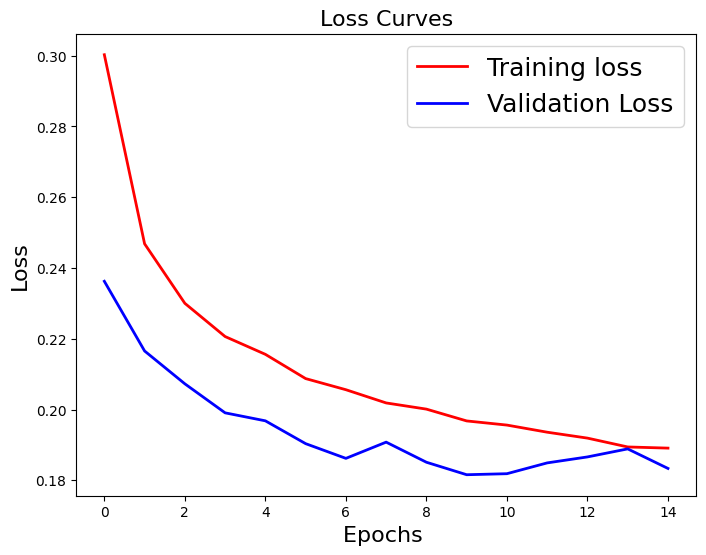

In [72]:
from matplotlib import pyplot as plt
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'],'r',linewidth=2.0)
plt.plot(history.history['val_loss'],'b',linewidth=2.0)
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)
  

In [73]:
test_loss = model.evaluate(
    [X_movie_test, X_user_test],
    y_test,
    verbose=0
)

print(f"Test MSE: {test_loss}")
print(f"Test RMSE: {np.sqrt(test_loss)}")

Test MSE: [0.18158267438411713, 0.3405819535255432]
Test RMSE: [0.42612519 0.583594  ]


In [87]:
age_mapping = {0.2 : 'teen', 0.4 : 'young_adult', 0.7 : 'adult', 0.9 : 'senior'}

In [88]:
def create_random_user_profile():
    # creating with 70% chance a user with specific taste, and 30% with mixed taste
    if np.random.random() < 0.7:
        archetype = np.random.choice(list(archetypes.keys()))
        preferences = archetypes[archetype].copy()
    else:
        preferences = {genre: np.random.beta(2, 2) for genre in one_hot_genre_cols}

    # Add outliars for realism
    for genre in preferences:
        preferences[genre] = np.clip(preferences[genre] + np.random.normal(0, 0.1), 0, 1)

    age_value = np.random.choice([0.2, 0.4, 0.7, 0.9])
    context = np.random.choice(['alone', 'partner', 'family', 'friends'])

    user_profile = {
        'age_normalized': age_value,          # broj za model
        'age_group': age_mapping[age_value],  # label za prikaz
        'viewing_context': context,
        'archetype': archetype if 'archetype' in locals() else 'mixed'
    }

    for genre in one_hot_genre_cols:
        user_profile[genre] = preferences.get(genre, 0.3)

    return user_profile

In [89]:
def predict_top_movies_for_user(user_profile, model, movie_features, movies_df, top_n=10):
    
    user_genre_values = [user_profile[genre] for genre in one_hot_genre_cols]
    user_features = np.array(user_genre_values, dtype=np.float32).reshape(1, -1)
    
    movie_features_array = movie_features[movie_feature_cols].values.astype(np.float32)
    
    user_features_repeated = np.repeat(user_features, len(movie_features_array), axis=0)
    
    predictions = model.predict([movie_features_array, user_features_repeated], 
                               batch_size=256, verbose=0)
    
    movie_features_with_pred = movie_features.copy()
    movie_features_with_pred['predicted_rating'] = predictions
    
    movie_predictions = movie_features_with_pred.merge(
        movies_df[['movieId', 'title', 'genres', 'year']], 
        on='movieId'
    )
    
    top_movies = movie_predictions.sort_values('predicted_rating', ascending=False).head(top_n)
    
    return top_movies[['movieId', 'title', 'genres', 'year', 'predicted_rating']]

In [90]:
user1 = create_random_user_profile()
print("User Profile:")
print(f"  Archetype: {user1['archetype']}")

age_label = age_mapping.get(user1['age_normalized'])
print(f"  Age Group: {age_label}")
print(f"  Viewing Context: {user1['viewing_context']}")

user_genres = [(genre, user1[genre]) for genre in one_hot_genre_cols if user1[genre] > 0.5]
user_genres.sort(key=lambda x: x[1], reverse=True)
print(f"  Top Genre Preferences:")
for genre, score in user_genres[:5]:
    print(f"    {genre.replace('genre_', '')}: {score:.2f}")

print("\nTop 10 Movie Recommendations for this user:")
recommendations1 = predict_top_movies_for_user(user1, model, movie_features, movies_df, top_n=10)

for i, (_, row) in enumerate(recommendations1.iterrows(), 1):
    print(f"{i}. {row['title']} ({int(row['year'])})")
    print(f"   Genres: {row['genres']}")
    print(f"   Predicted Rating: {row['predicted_rating']:.2f}")
    print()


User Profile:
  Archetype: sci_fi_fan
  Age Group: young_adult
  Viewing Context: family
  Top Genre Preferences:
    Fantasy: 0.95
    Sci-Fi: 0.90
    Action: 0.63

Top 10 Movie Recommendations for this user:
1. Logan (2017) (2017)
   Genres: Action|Sci-Fi
   Predicted Rating: 3.45

2. Doctor Who: Voyage Of The Damned (2007) (2007)
   Genres: Action|Sci-Fi
   Predicted Rating: 3.45

3. Ink (2009) (2009)
   Genres: Action|Fantasy|Sci-Fi
   Predicted Rating: 3.44

4. District 13: Ultimatum (Banlieue 13 - Ultimatum) (2009) (2009)
   Genres: Action|Sci-Fi
   Predicted Rating: 3.44

5. Dredd (2012) (2012)
   Genres: Action|Sci-Fi
   Predicted Rating: 3.44

6. Nirvana (1997) (1997)
   Genres: Action|Sci-Fi
   Predicted Rating: 3.44

7. Incredible Hulk, The (2008) (2008)
   Genres: Action|Sci-Fi
   Predicted Rating: 3.43

8. Blood of Heroes, The (Salute of the Jugger, The) (1989) (1989)
   Genres: Action|Sci-Fi
   Predicted Rating: 3.43

9. War of the Worlds (2005) (2005)
   Genres: Action|

In [91]:
viewing_context_mapping = {
    'alone': 1.0,
    'partner': 0.7,
    'family': 0.4,
    'friends': 0.6
}

In [92]:
def create_known_user_profile(
    liked_genres,
    age_group,
    viewing_context,
    base_pref=0.2,
    strong_pref=0.9
):
    user_profile = {}

    for genre in one_hot_genre_cols:
        user_profile[genre] = base_pref

    for genre in liked_genres:
        key = f'genre_{genre}'
        if key in user_profile:
            user_profile[key] = strong_pref

    user_profile['age_normalized'] = age_mapping[age_group]

    user_profile['viewing_context'] = viewing_context_mapping[viewing_context]

    return user_profile


In [94]:
Petar = create_known_user_profile(
    liked_genres=['Sci-Fi', 'Mystery', 'Action'],
    age_group=0.4,
    viewing_context='alone'
)

In [95]:
user_features = np.array(
    [Petar[col] for col in user_genre_pref_cols],
    dtype=np.float32
).reshape(1, -1)

In [96]:
print("\nTop 10 Movie Recommendations for this user:")
recommendations2 = predict_top_movies_for_user(Petar, model, movie_features, movies_df, top_n=10)

for i, (_, row) in enumerate(recommendations2.iterrows(), 1):
    print(f"{i}. {row['title']} ({int(row['year'])})")
    print(f"   Genres: {row['genres']}")
    print(f"   Predicted Rating: {row['predicted_rating']:.2f}")
    print()


Top 10 Movie Recommendations for this user:
1. Doctor Who: Voyage Of The Damned (2007) (2007)
   Genres: Action|Sci-Fi
   Predicted Rating: 3.21

2. Logan (2017) (2017)
   Genres: Action|Sci-Fi
   Predicted Rating: 3.20

3. Nirvana (1997) (1997)
   Genres: Action|Sci-Fi
   Predicted Rating: 3.20

4. District 13: Ultimatum (Banlieue 13 - Ultimatum) (2009) (2009)
   Genres: Action|Sci-Fi
   Predicted Rating: 3.19

5. Dredd (2012) (2012)
   Genres: Action|Sci-Fi
   Predicted Rating: 3.19

6. Ink (2009) (2009)
   Genres: Action|Fantasy|Sci-Fi
   Predicted Rating: 3.19

7. Blood of Heroes, The (Salute of the Jugger, The) (1989) (1989)
   Genres: Action|Sci-Fi
   Predicted Rating: 3.18

8. Incredible Hulk, The (2008) (2008)
   Genres: Action|Sci-Fi
   Predicted Rating: 3.17

9. Death Race 2000 (1975) (1975)
   Genres: Action|Sci-Fi
   Predicted Rating: 3.17

10. Starship Troopers (1997) (1997)
   Genres: Action|Sci-Fi
   Predicted Rating: 3.17

